In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [38]:
dx = (200 - 0) / 100
dy = (100 - (-100)) / 100

xcoord(i1_) = 0 + (i1_ - 1) * dx
ycoord(i2_) = -100 + (i2_ - 1) * dy

ycoord (generic function with 1 method)

In [68]:
collective_neg_pos_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end

        mmb = mm[idx,idy]

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            mm[idx,idy] += S

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed* cos(theta)
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed* cos(theta)
                    vy = speed* sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

                        
            xmin, xmax = simBox[1,1], simBox[1,2]
            ymin, ymax = simBox[2,1], simBox[2,2]

            # X walls (Neumann)
            if x < xmin
                x = xmin
                vx = -vx
            elseif x > xmax
                x = xmax
                vx = -vx
            end

            # Top wall (Neumann)
            if y > ymax
                y = ymax
                vy = -vy
            end

            # Bottom wall (geometry)
            if y < wall_y(x)
                y = wall_y(x)
                vy = -vy
            end

    end,


    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm  + ve*@∂(1, mm)
            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(2,1) # top NBC (newmann)
            mm = mm[i1_, NMedium[2]-1]

        elseif @mediumBorder(2,-1)

            x = xcoord(i1_)
            y = ycoord(i2_)

            ywall = wall_y(x)

            # Neumann reflection
            mm = mm[i1_, 2]

            # mask outside domain
            if y < ywall
                mm = 0.0
            end
        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    dt

In [81]:
com = Community(
    collective_neg_pos_model,
    N=100,
    dt=0.01,
    simBox = [-100.0 100.0; -100.0 100.0],
    NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 10
com.delta = 0.01
com.ve = 0

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)

com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 
com.S = 0.1


0.1

In [82]:
outfile = "cript_test.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=100)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    # meta = JLD2.Group(file, "meta")
    # meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    # meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


CompositeException: TaskFailedException

    nested task error: BoundsError: attempt to access 100×100 Matrix{Float64} at index [101, 1]
    Stacktrace:
     [1] getindex
       @ .\essentials.jl:14 [inlined]
     [2] macro expansion
       @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:91 [inlined]
     [3] macro expansion
       @ C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\src\AgentStructure\auxiliar.jl:166 [inlined]
     [4] (::var"#321#threadsfor_fun#218"{var"#321#threadsfor_fun#216#219"{SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}, SubArray{Float64, 1, Matrix{Float64}, Tuple{Int64, Base.S

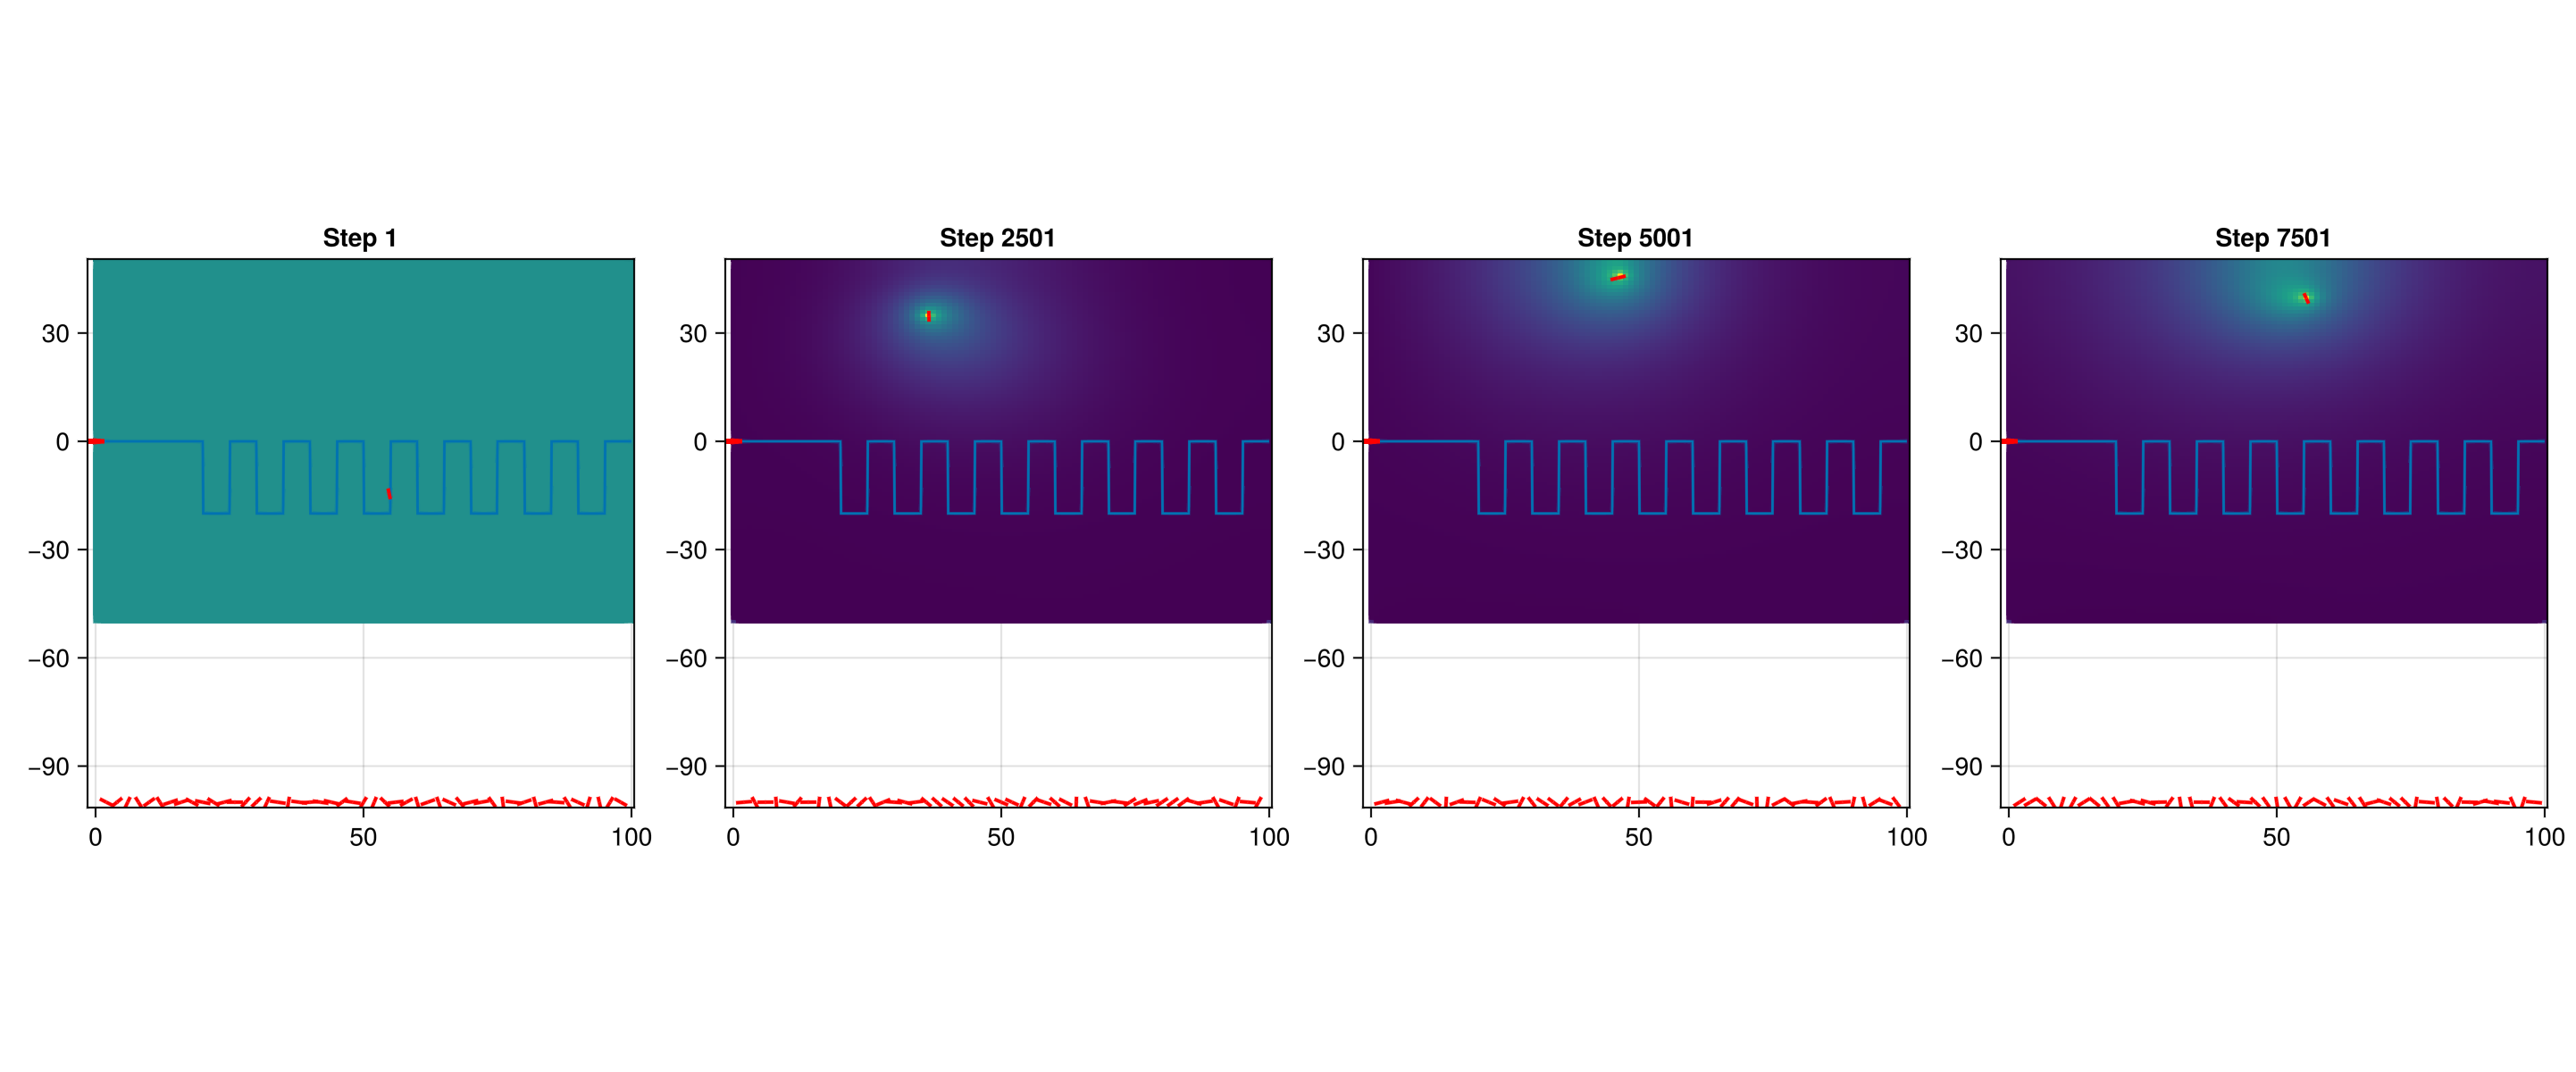

GLMakie.Screen(...)

In [62]:
fig4 = Figure(size=(900*4,600))
steps = 10000
model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
# steps_to_plot = [1, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

jldopen("cript_test.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 1)
        y = Vector{Float64}(undef, 1)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig4[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:100
        ys = [wall_y(x) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3

            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [19]:
function is_wall(x, y; w=10, d=20)
    # Base wall at y = 0
    if y == 0
        return iseven(fld(x, w))  # alternating solid / gap
    end

    # Indentations going downward
    if y < 0
        return isodd(fld(x, w)) && y >= -d
    end

    return false
end

is_wall (generic function with 1 method)

In [ ]:
function wall_y_test(x; w=10.0, d=20.0)
    return -d * floor((1 + sign(sin(2π * x / w))) / 2)
end


wall_y (generic function with 1 method)

In [55]:
function wall_y(x; xstart=20.0, xend=180.0, w=10.0, d=20.0)
    
    # outside wall region → no wall (or treat as flat boundary)
    if x < xstart || x > xend
        return 0.0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    return -d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

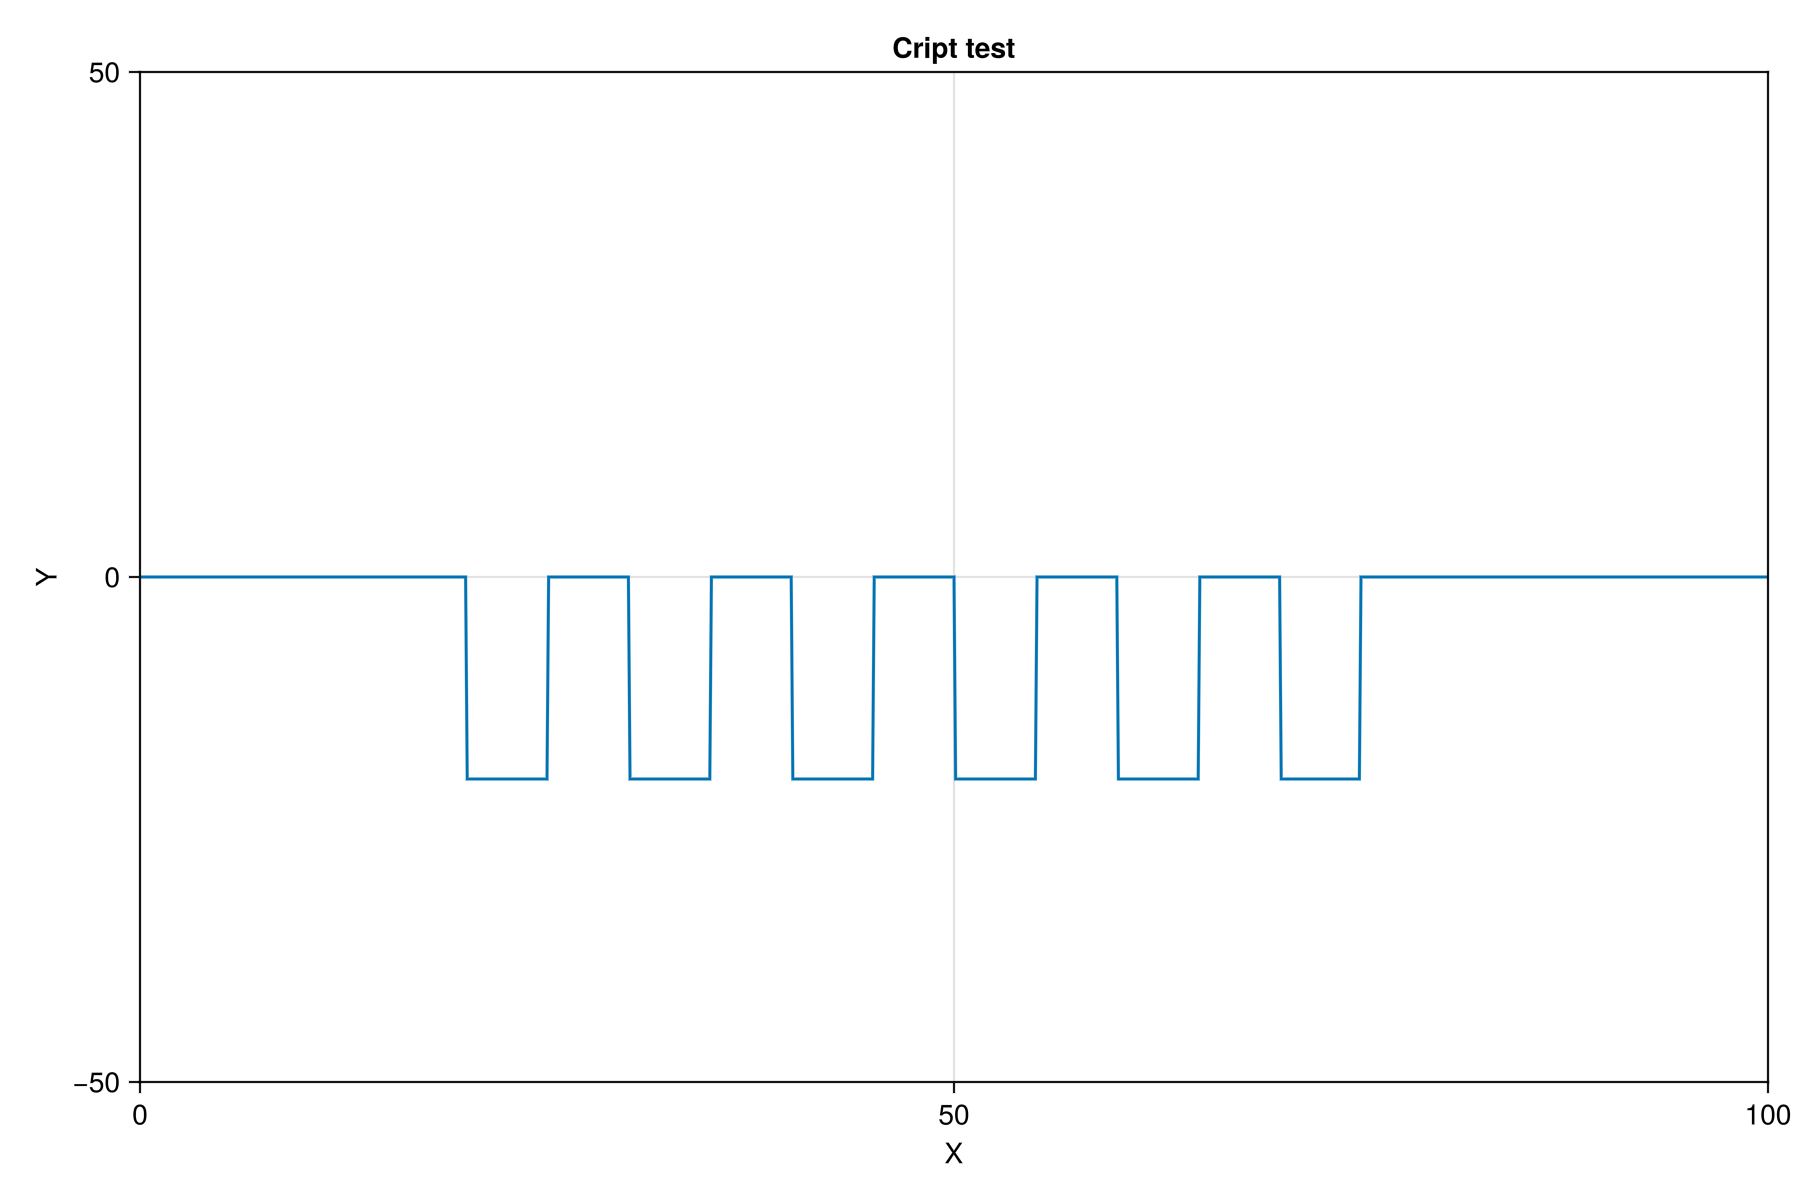

In [27]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = 0:0.1:100
ys = [wall_y(x) for x in xs]

lines!(ax, xs, ys)
xlims!(ax, 0, 100)
ylims!(ax, -50, 50)
fig

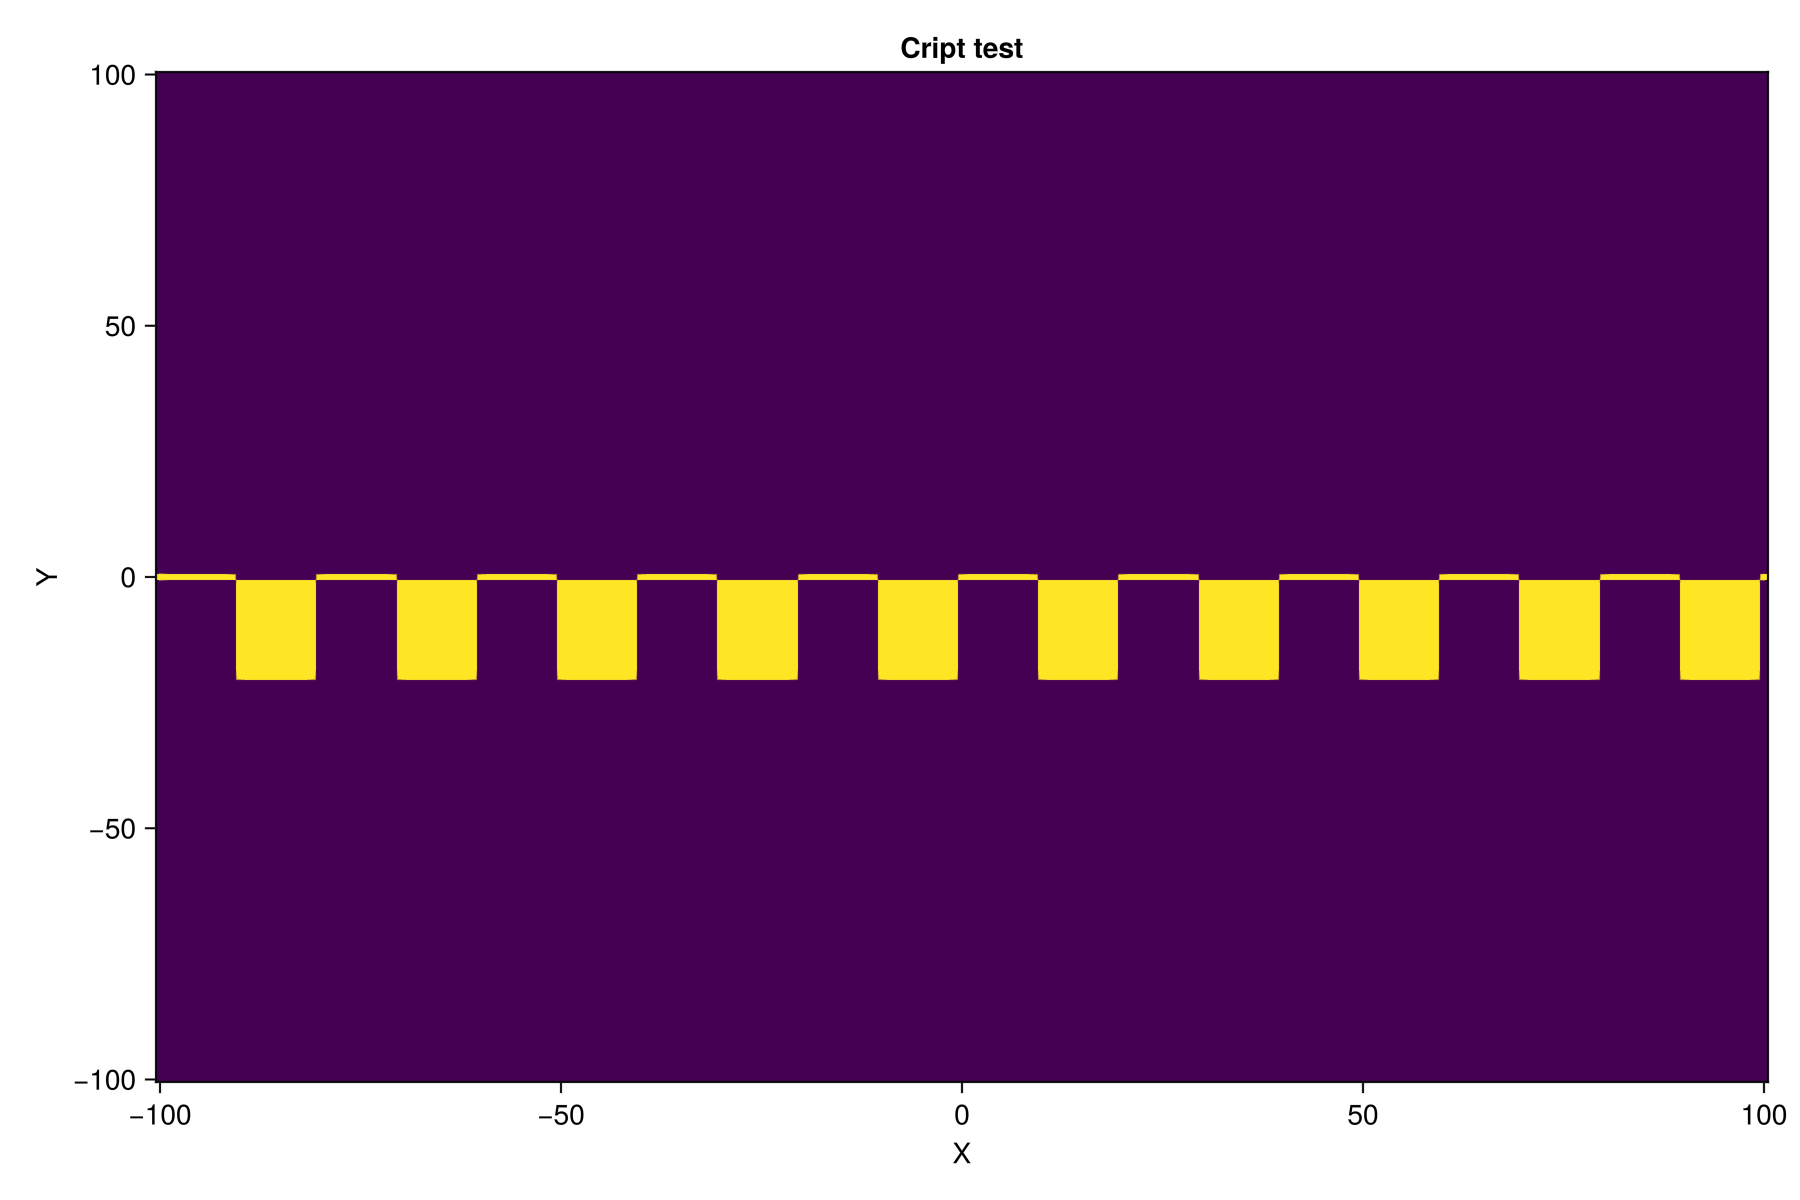

In [20]:
fig2 = Figure(size=(900,600))
ax2 = Axis(fig2[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = -100:1:100
ys = -100:1:100
Z = [is_wall(x, y) ? 1.0 : 0.0 for x in xs, y in ys]
heatmap!(ax2, xs, ys, Z)
fig2